middle axis: I = 0.0833 kg*m^2, alpha = 1.20 rad/s^2, turned 539 deg in 4 s
end axis:    I = 0.3333 kg*m^2, alpha = 0.30 rad/s^2, turned 135 deg in 4 s
ratio of angles turned = 4.00
saved the GIF


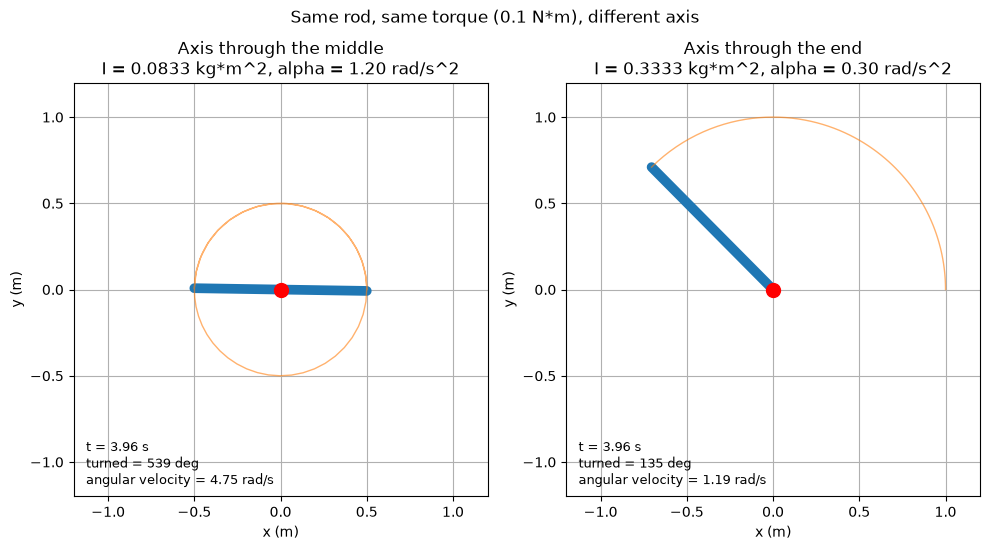

In [1]:
import os
import numpy as np  # type: ignore
import matplotlib.pyplot as plt  # type: ignore
from matplotlib.animation import FuncAnimation, PillowWriter  # type: ignore
from datetime import datetime

RESULT_DIR = os.path.join(os.getcwd(), "result")
os.makedirs(RESULT_DIR, exist_ok=True)
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# ─────────────────────────────────────────────
# STEP 1: Two identical rods, one torque, two different axes
#
# What we have: the same rod (mass m, length L) twice, pushed by the SAME constant torque.
#   left rod:  axis through the middle (center of mass), moment of inertia m L^2 / 12
#   right rod: axis through the end,                     moment of inertia m L^2 / 3
# What we want: to SEE how the rod spins, and how the axis changes the spin.
# Why it is needed: the rotation law  torque = (moment of inertia) x (angular acceleration)
#   says the rod with the smaller moment of inertia speeds up its spin faster.
#
# No gravity here and no friction, so the only thing acting is the torque.
# ─────────────────────────────────────────────

ROD_MASS = 1.0  # kg, foundational
ROD_LENGTH = 1.0  # m, foundational
TORQUE = 0.1  # N*m, foundational, the same push on both rods
START_ANGLE_DEG = 0.0  # deg, foundational, both rods start pointing along +x, at rest
DURATION = 4.0  # s, foundational
FPS = 25  # frames per second of the GIF, foundational (a drawing choice)

I_MIDDLE = ROD_MASS * ROD_LENGTH**2 / 12  # kg*m^2, derived
I_END = ROD_MASS * ROD_LENGTH**2 / 3  # kg*m^2, derived

alpha_middle = TORQUE / I_MIDDLE  # rad/s^2, derived: angular acceleration = torque / moment of inertia
alpha_end = TORQUE / I_END  # rad/s^2, derived

# ─────────────────────────────────────────────
# STEP 2: The motion
#
# Constant angular acceleration, starting at rest (these are the angular versions of your linear motion rules):
#   angular velocity  w(t) = alpha t                      (rad/s)
#   angle         theta(t) = theta0 + (1/2) alpha t^2     (rad)
# ─────────────────────────────────────────────

time_log = np.arange(0, DURATION, 1 / FPS)  # s
theta0 = np.deg2rad(START_ANGLE_DEG)  # rad
theta_middle = theta0 + 0.5 * alpha_middle * time_log**2  # rad
theta_end = theta0 + 0.5 * alpha_end * time_log**2  # rad
omega_middle = alpha_middle * time_log  # rad/s
omega_end = alpha_end * time_log  # rad/s

print(f"middle axis: I = {I_MIDDLE:.4f} kg*m^2, alpha = {alpha_middle:.2f} rad/s^2, turned {np.rad2deg(theta_middle[-1] - theta0):.0f} deg in {DURATION:.0f} s")
print(f"end axis:    I = {I_END:.4f} kg*m^2, alpha = {alpha_end:.2f} rad/s^2, turned {np.rad2deg(theta_end[-1] - theta0):.0f} deg in {DURATION:.0f} s")
print(f"ratio of angles turned = {(theta_middle[-1] - theta0) / (theta_end[-1] - theta0):.2f}")

# ─────────────────────────────────────────────
# STEP 3: Animated GIF
#
# Each rod is drawn as a line from one end to the other. The red dot is the axis.
# The orange trail is the path of the rod's far tip.
# Positions along the rod are measured from the axis:
#   middle axis: the rod runs from -L/2 to +L/2
#   end axis:    the rod runs from 0 to +L
# ─────────────────────────────────────────────

cases = [
    ("Axis through the middle", -ROD_LENGTH / 2, ROD_LENGTH / 2, theta_middle, omega_middle, I_MIDDLE, alpha_middle),
    ("Axis through the end", 0.0, ROD_LENGTH, theta_end, omega_end, I_END, alpha_end),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5))
rod_lines, tip_trails, texts = [], [], []

for ax, (title, start, stop, theta, omega, inertia, alpha) in zip(axes, cases):
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect("equal")
    ax.grid(True)
    ax.set_title(f"{title}\nI = {inertia:.4f} kg*m^2, alpha = {alpha:.2f} rad/s^2")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    (rod_line,) = ax.plot([], [], "-", linewidth=7, color="C0", solid_capstyle="round")
    (trail,) = ax.plot([], [], "-", linewidth=1, color="C1", alpha=0.6)
    ax.plot([0], [0], "o", markersize=10, color="red", zorder=5)  # the axis
    text = ax.text(0.03, 0.03, "", transform=ax.transAxes, fontsize=9)
    rod_lines.append(rod_line)
    tip_trails.append(trail)
    texts.append(text)

fig.suptitle(f"Same rod, same torque ({TORQUE} N*m), different axis")


def update(frame_index):
    for k, (title, start, stop, theta, omega, inertia, alpha) in enumerate(cases):
        direction = np.array([np.cos(theta[frame_index]), np.sin(theta[frame_index])])  # unit vector along the rod
        end_a = start * direction  # m, one end of the rod
        end_b = stop * direction  # m, the other end of the rod
        rod_lines[k].set_data([end_a[0], end_b[0]], [end_a[1], end_b[1]])
        trail_x = stop * np.cos(theta[: frame_index + 1])
        trail_y = stop * np.sin(theta[: frame_index + 1])
        tip_trails[k].set_data(trail_x, trail_y)
        texts[k].set_text(f"t = {time_log[frame_index]:.2f} s\nturned = {np.rad2deg(theta[frame_index] - theta0):.0f} deg\nangular velocity = {omega[frame_index]:.2f} rad/s")
    return rod_lines + tip_trails + texts


fig.tight_layout()
animation = FuncAnimation(fig, update, frames=len(time_log), interval=1000 / FPS, blit=False)
animation.save(os.path.join(RESULT_DIR, f"rod_spin_two_axes_{TIMESTAMP}.gif"), writer=PillowWriter(fps=FPS))
print("saved the GIF")

# a still image of the last frame, so the final angles can be compared at a glance
update(len(time_log) - 1)
fig.savefig(os.path.join(RESULT_DIR, f"rod_spin_two_axes_last_frame_{TIMESTAMP}.png"))

plt.show()

saved the GIF


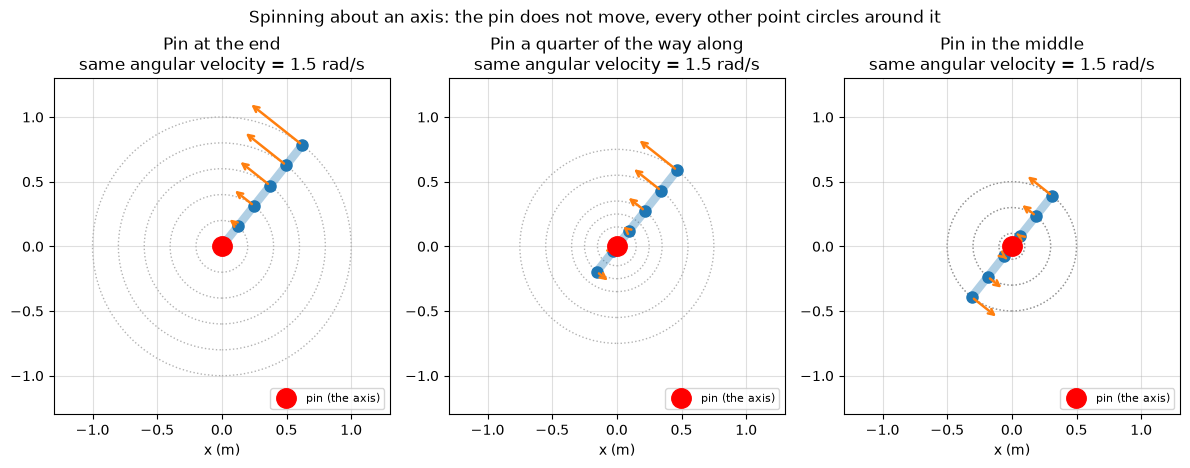

In [2]:
import os
import numpy as np  # type: ignore
import matplotlib.pyplot as plt  # type: ignore
from matplotlib.animation import FuncAnimation, PillowWriter  # type: ignore
from datetime import datetime

RESULT_DIR = os.path.join(os.getcwd(), "result")
os.makedirs(RESULT_DIR, exist_ok=True)
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# ─────────────────────────────────────────────
# STEP 1: One rod, three different pins
#
# What we have: the same rod (length L), turning at the same angular velocity W in all three panels.
# What we want: to SEE what "spins about an axis" means.
# Idea: the axis is a pin through the rod. The point of the rod at the pin does not move.
#       Every other point of the rod moves on a circle around the pin.
#
# The pin sits at distance PIN_POSITION from the left end of the rod (measured along the rod).
# ─────────────────────────────────────────────

ROD_LENGTH = 1.0  # m, foundational
ANGULAR_VELOCITY = 1.5  # rad/s, foundational, the same in every panel
DURATION = 4.2  # s, foundational, about one full turn (4.2 s x 1.5 rad/s = 6.3 rad)
FPS = 25  # foundational (a drawing choice)
ARROW_SCALE = 0.35  # drawing scale: 1 m/s of speed is drawn as an arrow 0.35 m long

pin_cases = [
    ("Pin at the end", 0.0),
    ("Pin a quarter of the way along", 0.25 * ROD_LENGTH),
    ("Pin in the middle", 0.5 * ROD_LENGTH),
]
points_along_rod = np.linspace(0, ROD_LENGTH, 6)  # m, six marked points on the rod, measured from the left end

time_log = np.arange(0, DURATION, 1 / FPS)  # s
theta = ANGULAR_VELOCITY * time_log  # rad, the rod turns at constant angular velocity

# ─────────────────────────────────────────────
# STEP 2: Draw the three panels
#
# For a marked point at signed distance d from the pin (m), measured along the rod:
#   position  = d x (cos(theta), sin(theta))              (m)
#   velocity  = w x d x (-sin(theta), cos(theta))         (m/s), size |w d|, tangent to the circle
# The point at the pin has d = 0, so its velocity is exactly 0.
# The faint circle around the pin is the path of that point (radius |d|).
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(12, 4.6))
rod_lines, dot_artists, arrow_lists, time_texts = [], [], [], []

for ax, (title, pin_position) in zip(axes, pin_cases):
    distances = points_along_rod - pin_position  # m, signed distance of each marked point from the pin
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.4)
    ax.set_title(f"{title}\nsame angular velocity = {ANGULAR_VELOCITY} rad/s")
    ax.set_xlabel("x (m)")
    for d in distances:
        if abs(d) > 1e-9:
            ax.add_patch(plt.Circle((0, 0), abs(d), fill=False, linestyle=":", color="gray", alpha=0.6))  # path of that point
    (rod_line,) = ax.plot([], [], "-", linewidth=6, color="C0", alpha=0.35, solid_capstyle="round")
    (dots,) = ax.plot([], [], "o", markersize=8, color="C0")
    ax.plot([0], [0], "o", markersize=14, color="red", zorder=5, label="pin (the axis)")
    ax.legend(loc="lower right", fontsize=8)
    rod_lines.append(rod_line)
    dot_artists.append(dots)
    arrow_lists.append([])

fig.suptitle("Spinning about an axis: the pin does not move, every other point circles around it")


def update(frame_index):
    angle = theta[frame_index]
    direction = np.array([np.cos(angle), np.sin(angle)])  # unit vector along the rod
    tangent = np.array([-np.sin(angle), np.cos(angle)])  # unit vector at a right angle to the rod
    for k, (title, pin_position) in enumerate(pin_cases):
        distances = points_along_rod - pin_position  # m
        positions = np.outer(distances, direction)  # m, one row per marked point
        rod_ends = np.array([distances.min() * direction, distances.max() * direction])
        rod_lines[k].set_data(rod_ends[:, 0], rod_ends[:, 1])
        dot_artists[k].set_data(positions[:, 0], positions[:, 1])
        for old_arrow in arrow_lists[k]:
            old_arrow.remove()
        arrow_lists[k].clear()
        for d, position in zip(distances, positions):
            if abs(d) < 1e-9:
                continue  # the point at the pin has speed 0, so it gets no arrow
            velocity = ANGULAR_VELOCITY * d * tangent  # m/s
            tip = position + ARROW_SCALE * velocity
            arrow = axes[k].annotate("", xy=tip, xytext=position, arrowprops=dict(arrowstyle="->", color="C1", lw=1.8))
            arrow_lists[k].append(arrow)
    return rod_lines + dot_artists


fig.tight_layout()
animation = FuncAnimation(fig, update, frames=len(time_log), interval=1000 / FPS, blit=False)
animation.save(os.path.join(RESULT_DIR, f"rod_spin_pin_positions_{TIMESTAMP}.gif"), writer=PillowWriter(fps=FPS))
print("saved the GIF")

update(int(0.6 / (1 / FPS)))  # one still frame at t = 0.6 s
fig.savefig(os.path.join(RESULT_DIR, f"rod_spin_pin_positions_still_{TIMESTAMP}.png"))

plt.show()